In [1]:
pip install fsspec


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install huggingface_hub

     -------------------------------------- 516.0/516.0 kB 4.6 MB/s eta 0:00:00
     ------------------------------------- 201.0/201.0 kB 11.9 MB/s eta 0:00:00
     ---------------------------------------- 47.1/47.1 kB ? eta 0:00:00
  Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
     ---------------------------------------- 2.9/2.9 MB 26.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2022.7.1
    Uninstalling fsspec-2022.7.1:
      Successfully uninstalled fsspec-2022.7.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
# First dataset
spotify = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv")
spotify.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [2]:
# Second dataset
new=pd.read_csv(r'C:\Users\Kendall Underwood\Downloads\Grammy Award Nominees and Winners 1958-2024.csv')
new

,Unnamed: 0,Year,Ceremony,Award ID,Award Type,Award Name,Work,Nominee,Winner
0,0,1958,1,587,Work,Best Recording For Children,Childrens' Marching Song (Album),Cyril Stapleton,False
1,1,1958,1,587,Work,Best Recording For Children,"Mommy, Give Me A Drinka Water (Album)",Danny Kaye,False
2,2,1958,1,587,Work,Best Recording For Children,The Witch Doctor,David Seville And The Chipmunks,False
3,3,1958,1,587,Work,Best Recording For Children,Tubby The Tuba,Jose Ferrer,False
4,4,1958,1,587,Work,Best Recording For Children,Fun In Shariland (Album),Shari Lewis And Lambchop,False
...,...,...,...,...,...,...,...,...,...
25300,25300,2024,67,2432,Work,Best Dance Pop Recording,"yes, and?",Ariana Grande,False
25301,25301,2024,67,2432,Work,Best Dance Pop Recording,L’AMOUR DE MA VIE [OVER NOW EXTENDED EDIT],Billie Eilish,False
25302,25302,2024,67,2432,Work,Best Dance Pop Recording,Make You Mine,Madison Beer,False
25303,25303,2024,67,2432,Work,Best Dance Pop Recording,Got Me Started,Troye Sivan,False


In [3]:
# the two datasets joined
new['track_name']=new['Work']
nominees=new['track_name'].unique()
spotify['nominated']=[x in nominees for x in spotify['track_name']]

In [4]:
spotify.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre', 'nominated'],
      dtype='object')

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:

spotify = spotify.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'album_name', 'artists'], errors='ignore')


categorical_cols = spotify.select_dtypes(include=['object', 'category']).columns


label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    spotify[col] = le.fit_transform(spotify[col].astype(str))
    label_encoders[col] = le


if spotify['explicit'].dtype == 'bool':
    spotify['explicit'] = spotify['explicit'].astype(int)


X = spotify.drop(columns=['nominated'])
y = spotify['nominated']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print("\nTop Features:\n", importances.sort_values(ascending=False).head(10))

✅ Accuracy: 0.9642982456140351

Classification Report:
               precision    recall  f1-score   support

       False       0.96      1.00      0.98     21506
        True       1.00      0.37      0.54      1294

    accuracy                           0.96     22800
   macro avg       0.98      0.69      0.76     22800
weighted avg       0.97      0.96      0.96     22800


Confusion Matrix:
 [[21505     1]
 [  813   481]]

Top Features:
 popularity      0.104583
duration_ms     0.086285
valence         0.086114
acousticness    0.083328
liveness        0.082785
speechiness     0.077539
tempo           0.076492
danceability    0.074531
energy          0.073316
loudness        0.072997
dtype: float64


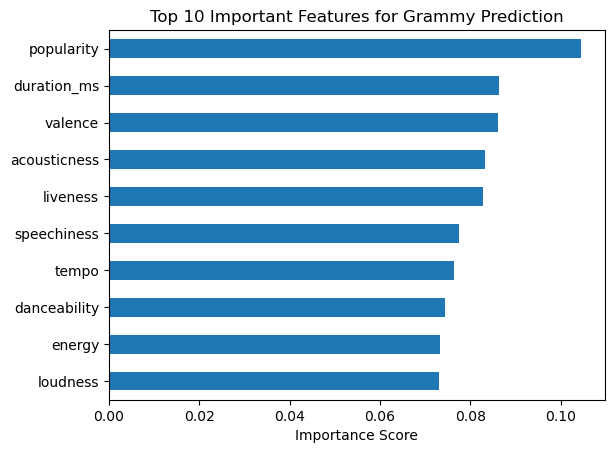

In [7]:
import matplotlib.pyplot as plt

importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Important Features for Grammy Prediction')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

In [8]:
# Checkpoint 3- Using Gradient Boosting Machine as the Model Variant

spotify = spotify.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'album_name', 'artists'], errors='ignore')


categorical_cols = spotify.select_dtypes(include=['object', 'category']).columns

from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    spotify[col] = le.fit_transform(spotify[col].astype(str))
    label_encoders[col] = le


if spotify['explicit'].dtype == 'bool':
    spotify['explicit'] = spotify['explicit'].astype(int)


X = spotify.drop(columns=['nominated'])
y = spotify['nominated']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


from sklearn.ensemble import GradientBoostingClassifier

gbm_model = GradientBoostingClassifier(
    n_estimators=200,      
    learning_rate=0.05,    
    max_depth=3,          
    random_state=42
)

gbm_model.fit(X_train, y_train)


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = gbm_model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


importances = pd.Series(gbm_model.feature_importances_, index=X.columns)
print("\nTop Features:\n", importances.sort_values(ascending=False).head(10))


✅ Accuracy: 0.9442105263157895

Classification Report:
               precision    recall  f1-score   support

       False       0.94      1.00      0.97     21506
        True       0.96      0.02      0.03      1294

    accuracy                           0.94     22800
   macro avg       0.95      0.51      0.50     22800
weighted avg       0.94      0.94      0.92     22800


Confusion Matrix:
 [[21505     1]
 [ 1271    23]]

Top Features:
 popularity          0.329557
valence             0.093253
track_genre         0.075514
speechiness         0.071454
duration_ms         0.066371
danceability        0.061613
tempo               0.058277
instrumentalness    0.057800
liveness            0.056906
acousticness        0.053489
dtype: float64


In [9]:
# Doing cross validation on the two models for comaparison
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np


spotify = spotify.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'album_name', 'artists'], errors='ignore')

categorical_cols = spotify.select_dtypes(include=['object', 'category']).columns

from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    spotify[col] = le.fit_transform(spotify[col].astype(str))
    label_encoders[col] = le

if spotify['explicit'].dtype == 'bool':
    spotify['explicit'] = spotify['explicit'].astype(int)

X = spotify.drop(columns=['nominated'])
y = spotify['nominated']


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

gbm_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest CV
rf_cv_scores = cross_val_score(rf_model, X, y, cv=kfold, scoring='accuracy')
rf_cv_error = 1 - np.mean(rf_cv_scores)

# GBM CV
gbm_cv_scores = cross_val_score(gbm_model, X, y, cv=kfold, scoring='accuracy')
gbm_cv_error = 1 - np.mean(gbm_cv_scores)


print("Random Forest CV Accuracy Scores:", rf_cv_scores)
print("Random Forest Mean CV Accuracy:", np.mean(rf_cv_scores))
print("Random Forest CV Error:", rf_cv_error)

print("\nGradient Boosting CV Accuracy Scores:", gbm_cv_scores)
print("Gradient Boosting Mean CV Accuracy:", np.mean(gbm_cv_scores))
print("Gradient Boosting CV Error:", gbm_cv_error)


Random Forest CV Accuracy Scores: [0.96407895 0.9627193  0.96197368 0.96192982 0.96214912]
Random Forest Mean CV Accuracy: 0.9625701754385965
Random Forest CV Error: 0.037429824561403535

Gradient Boosting CV Accuracy Scores: [0.94421053 0.94263158 0.94083333 0.94179825 0.93986842]
Gradient Boosting Mean CV Accuracy: 0.9418684210526316
Gradient Boosting CV Error: 0.05813157894736842


In [10]:
# Comparing BIC
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss


spotify = spotify.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'album_name', 'artists'], errors='ignore')

categorical_cols = spotify.select_dtypes(include=['object', 'category']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    spotify[col] = le.fit_transform(spotify[col].astype(str))
    label_encoders[col] = le

if spotify['explicit'].dtype == 'bool':
    spotify['explicit'] = spotify['explicit'].astype(int)

X = spotify.drop(columns=['nominated'])
y = spotify['nominated']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

gbm = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


rf.fit(X_train, y_train)
gbm.fit(X_train, y_train)


def model_aic_bic(model, X, y, k):
    """
    Compute AIC and BIC for a classifier.
    - model: trained model
    - X: data
    - y: true labels
    - k: model complexity parameter (# trees)
    """

    
    probs = model.predict_proba(X)[:, 1]

   
    n = len(y)
    logL = -log_loss(y, probs, normalize=False)

    # AIC and BIC formulas from the slides
    AIC = 2 * k - 2 * logL
    BIC = k * np.log(n) - 2 * logL

    return AIC, BIC


k_rf = rf.n_estimators
k_gbm = gbm.n_estimators

rf_AIC, rf_BIC = model_aic_bic(rf, X_test, y_test, k_rf)
gbm_AIC, gbm_BIC = model_aic_bic(gbm, X_test, y_test, k_gbm)


print("Random Forest:")
print("  AIC:", rf_AIC)
print("  BIC:", rf_BIC)

print("\nGradient Boosting Machine:")
print("  AIC:", gbm_AIC)
print("  BIC:", gbm_BIC)


Random Forest:
  AIC: 7504.714348213061
  BIC: 8308.165929707315

Gradient Boosting Machine:
  AIC: 9364.206484273589
  BIC: 10971.109647262096


In [11]:
# Testing the third variant
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import log_loss, accuracy_score
import numpy as np




X = spotify.drop(columns=['nominated'])
y = spotify['nominated']


extra_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    max_depth=None
)


kfold = KFold(n_splits=5, shuffle=True, random_state=42)

extra_cv_scores = cross_val_score(extra_model, X, y, cv=kfold, scoring='accuracy')

extra_mean_accuracy = np.mean(extra_cv_scores)
extra_cv_error = 1 - extra_mean_accuracy

print("Extra Trees CV Accuracy Scores:", extra_cv_scores)
print("Extra Trees Mean CV Accuracy:", extra_mean_accuracy)
print("Extra Trees CV Error:", extra_cv_error)


extra_model.fit(X, y)


def compute_aic_bic(model, X, y, k):
    """
    Compute AIC and BIC using predicted probabilities.
    k = model complexity proxy (# of trees)
    """
    probs = model.predict_proba(X)[:, 1]
    
    
    n = len(y)
    logL = -log_loss(y, probs, normalize=False)

    AIC = 2 * k - 2 * logL
    BIC = k * np.log(n) - 2 * logL

    return AIC, BIC

k_extra = extra_model.n_estimators  # complexity parameter

extra_AIC, extra_BIC = compute_aic_bic(extra_model, X, y, k_extra)

print("\nExtra Trees AIC:", extra_AIC)
print("Extra Trees BIC:", extra_BIC)


y_pred = extra_model.predict(X)
full_accuracy = accuracy_score(y, y_pred)

print("\nExtra Trees Full Accuracy:", full_accuracy)


Extra Trees CV Accuracy Scores: [0.96583333 0.96486842 0.96460526 0.96394737 0.96447368]
Extra Trees Mean CV Accuracy: 0.9647456140350877
Extra Trees CV Error: 0.03525438596491226

Extra Trees AIC: 428.87830669276565
Extra Trees BIC: 2357.6690521680925

Extra Trees Full Accuracy: 0.9999561403508772
